# Differentiable vs Stochastic GOOP Pipelines

Side-by-side visualization of the same workload run through:
- **Stochastic**: per-photon delay sampling (Scintillation + TPB + TTS) + SER convolution.
- **Differentiable**: photon histogram convolved with a single composite `Response` = Scint ⊛ TPB ⊛ TTS ⊛ SER.

Both should match in expectation. Single-run differences are dominated by shot noise on per-photon delays.

Output is cropped to the first 10 000 ticks for readability.

In [1]:
import sys; sys.path.insert(0, "..")

import torch
import numpy as np
import matplotlib.pyplot as plt

from goop import (
    OpticalSimulator, OpticalSimConfig,
    DifferentiableOpticalSimulator,
    Response, ScintillationKernel, TPBExponentialKernel, TTSKernel, SERKernel,
    ScintillationBiexponentialDelay, TPBExponentialDelay, TTSDelay,
)
from goop.sampler import create_default_tof_sampler
from goop.delays import Delays

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Shared TOF sampler — both pipelines see the same photon-yield draws.
tof = create_default_tof_sampler(lazy=False, device=str(device))

TICK_NS = 1.0
GAIN = -45.0

# Stochastic config: SER kernel only, full delay chain on photons.
stoch_cfg = OpticalSimConfig(
    tof_sampler=tof,
    delays=Delays([
        ScintillationBiexponentialDelay(),
        TPBExponentialDelay(),
        TTSDelay(),
    ]),
    kernel=SERKernel(duration_ns=2000.0, device=device),
    device=str(device), tick_ns=TICK_NS, gain=GAIN,
)
stoch = OpticalSimulator(stoch_cfg)

# Differentiable config: Response = Scint ⊛ TPB ⊛ TTS ⊛ SER, no per-photon delays.
response = Response(
    kernels=[
        ScintillationKernel(device=device),
        TPBExponentialKernel(device=device),
        TTSKernel(device=device),
        SERKernel(duration_ns=2000.0, device=device),
    ],
    tick_ns=TICK_NS, device=device,
)
diff_cfg = OpticalSimConfig(
    tof_sampler=tof,
    delays=Delays([]),
    kernel=response,
    device=str(device), tick_ns=TICK_NS, gain=GAIN,
)
diff = DifferentiableOpticalSimulator(diff_cfg)
print(f"n_channels = {tof.n_channels}")

n_channels = 162


In [3]:
# Synthetic workload: a small line of edep-like sources on the cathode side.
n_pos = 200
pos = torch.zeros(n_pos, 3, device=device)
pos[:, 0] = -100.0
pos[:, 1] = torch.linspace(-150, 150, n_pos, device=device)
pos[:, 2] = torch.linspace(-150, 150, n_pos, device=device)
n_photons = torch.full((n_pos,), 10_000, device=device, dtype=torch.long)
t_step = torch.zeros(n_pos, device=device)

In [4]:
# Run both pipelines and deslice to dense arrays for imshow.
stoch_sw = stoch.simulate(pos, n_photons, t_step, stitched=True, add_baseline_noise=False)
diff_sw  = diff.simulate (pos, n_photons, t_step, stitched=True, add_baseline_noise=False)

stoch_wf = stoch_sw.deslice()
diff_wf  = diff_sw.deslice()

print(f"stoch: shape={tuple(stoch_wf.adc.shape)}, t0={stoch_wf.t0:.2f} ns")
print(f"diff : shape={tuple(diff_wf.adc.shape)},  t0={diff_wf.t0:.2f} ns")

stoch: shape=(162, 13302), t0=0.00 ns
diff : shape=(162, 15643),  t0=0.00 ns


In [5]:
# Align on a shared global time axis and crop to the first N_TICKS.
# (Recall: each pipeline picks its own t0 = times.min(). The diff pipeline has no
#  per-photon delays, so its t0 is earlier than the stoch t0.)
N_TICKS = 3000
t_start = min(stoch_wf.t0, diff_wf.t0)

def align(wf, t_start, n_ticks):
    n_ch = wf.adc.shape[0]
    out = torch.zeros(n_ch, n_ticks, device=wf.adc.device)
    offset = int(round((wf.t0 - t_start) / wf.tick_ns))
    if offset >= n_ticks:
        return out
    n_copy = min(wf.adc.shape[1], n_ticks - offset)
    out[:, offset:offset + n_copy] = wf.adc[:, :n_copy]
    return out

stoch_arr = align(stoch_wf, t_start, N_TICKS).cpu().numpy()
diff_arr  = align(diff_wf,  t_start, N_TICKS).cpu().numpy()
resid_arr = diff_arr - stoch_arr

print(f"stoch peak = {abs(stoch_arr).max():.1f}, diff peak = {abs(diff_arr).max():.1f}")
print(f"max |residual| = {abs(resid_arr).max():.1f} ADC")

stoch peak = 12620.2, diff peak = 9181.6
max |residual| = 7706.3 ADC


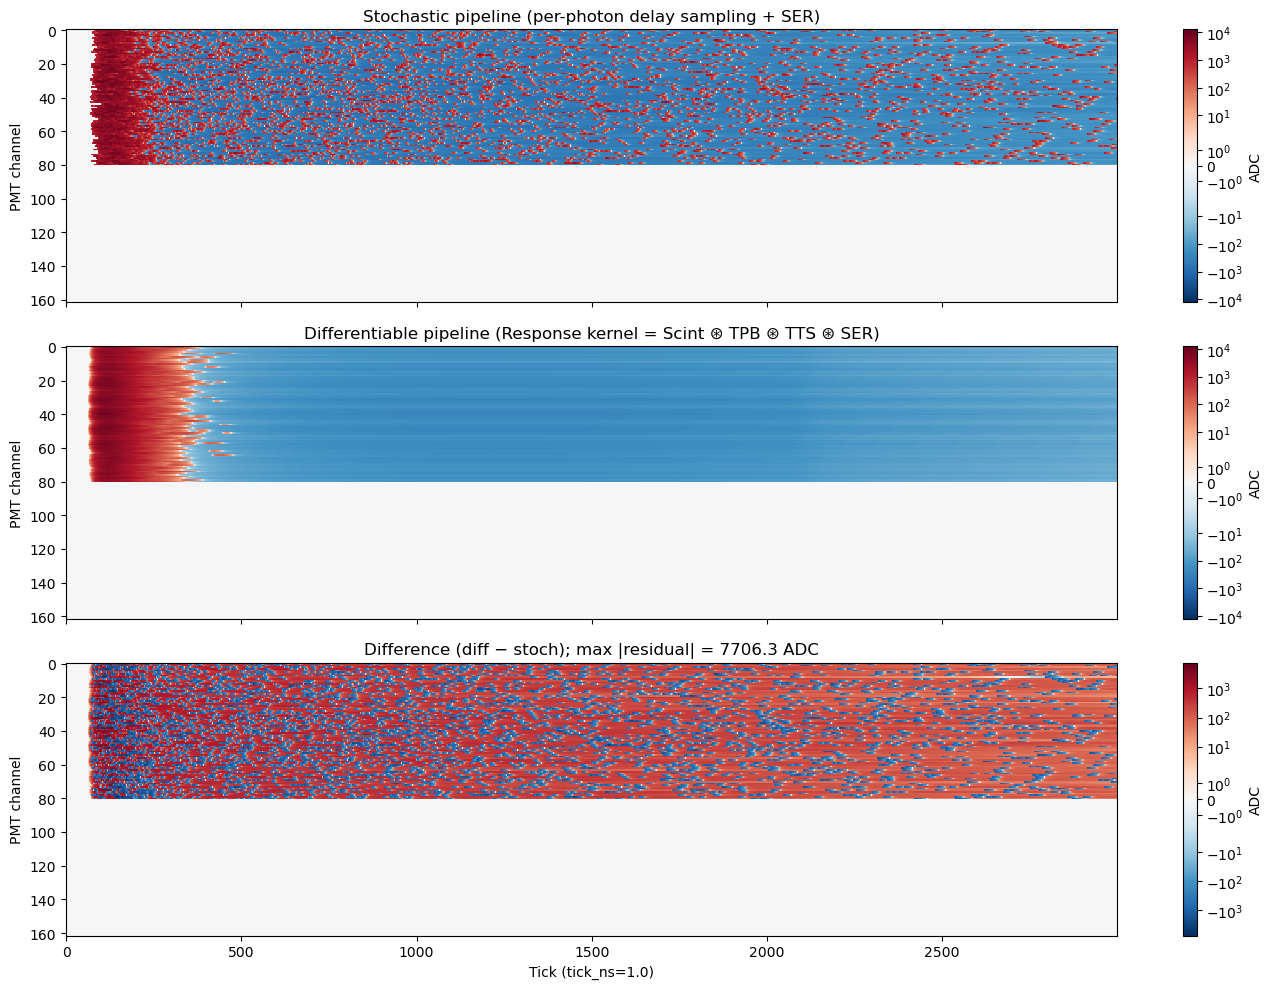

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
vmax = max(abs(stoch_arr).max(), abs(diff_arr).max())

im0 = axes[0].imshow(
    stoch_arr,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    interpolation="nearest",
    norm='symlog'
)
axes[0].set_title("Stochastic pipeline (per-photon delay sampling + SER)")
axes[0].set_ylabel("PMT channel")
plt.colorbar(im0, ax=axes[0], label="ADC")

im1 = axes[1].imshow(
    diff_arr,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    interpolation="nearest",
    norm='symlog'
)
axes[1].set_title("Differentiable pipeline (Response kernel = Scint ⊛ TPB ⊛ TTS ⊛ SER)")
axes[1].set_ylabel("PMT channel")
plt.colorbar(im1, ax=axes[1], label="ADC")

rmax = max(abs(resid_arr).max(), 1e-9)
im2 = axes[2].imshow(
    resid_arr,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-rmax,
    vmax=rmax,
    interpolation="nearest",
    norm='symlog'
)
axes[2].set_title(f"Difference (diff − stoch); max |residual| = {rmax:.1f} ADC")
axes[2].set_xlabel(f"Tick (tick_ns={TICK_NS})")
axes[2].set_ylabel("PMT channel")
plt.colorbar(im2, ax=axes[2], label="ADC")

plt.tight_layout()
plt.show()

## Per-channel slices

A single bright channel plotted as a 1-D trace, to make the shot-noise residual easier to read.

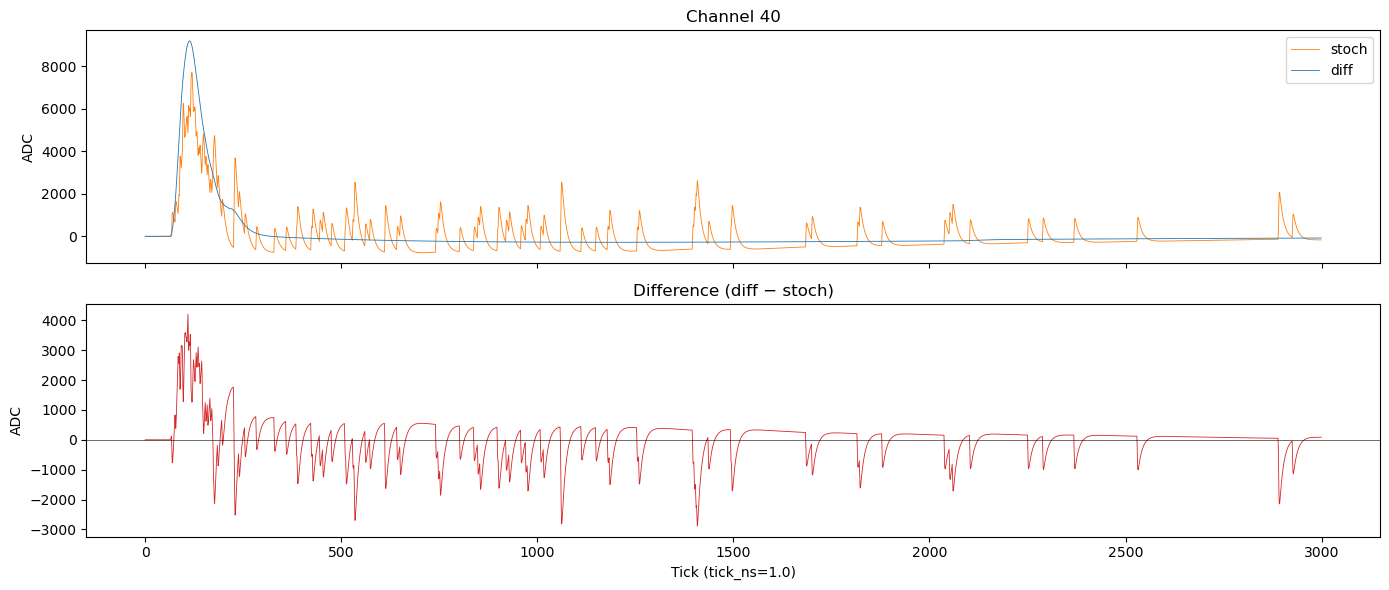

In [7]:
ch = int(np.argmax(np.abs(diff_arr).max(axis=1)))
ticks = np.arange(N_TICKS)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ticks, stoch_arr[ch], lw=0.6, color="tab:orange", label="stoch")
axes[0].plot(ticks, diff_arr[ch],  lw=0.6, color="tab:blue",   label="diff")
axes[0].set_title(f"Channel {ch}")
axes[0].set_ylabel("ADC")
axes[0].legend(loc="best")

axes[1].plot(ticks, resid_arr[ch], lw=0.6, color="tab:red")
axes[1].axhline(0, color="k", lw=0.4)
axes[1].set_title("Difference (diff − stoch)")
axes[1].set_xlabel(f"Tick (tick_ns={TICK_NS})")
axes[1].set_ylabel("ADC")

plt.tight_layout()
plt.show()

## Averaged stochastic vs differentiable

A *single* stochastic run places each photon at exactly one delayed time, so at late times (>2 µs) you see scattered individual PE spikes from the triplet-decay tail (each ~−1 kADC after gain). The differentiable pipeline puts the *expected* response at every bin — so at 2 µs the per-bin amplitude is ~1 ADC, indistinguishable from baseline at the imshow vmax.

Average many stochastic runs and the per-PE noise smooths into the same low-amplitude triplet tail that diff produces in one shot.

In [8]:
# Average N_RUNS stochastic runs to smooth out per-PE shot noise.
# Each run uses the same TOF draw seed via reset of the manual seed only on
# the delay sampling — but the TOFSampler.sample() also uses torch.poisson()
# (no manual seed), so each run still has independent photon-yield draws.
# That's fine here — averaging suppresses both yield and delay shot noise.
N_RUNS = 1000

stoch_accum = torch.zeros_like(stoch_wf.adc)
for _ in range(N_RUNS):
    sw = stoch.simulate(pos, n_photons, t_step, stitched=True, add_baseline_noise=False)
    wf = sw.deslice()
    n = min(stoch_accum.shape[1], wf.adc.shape[1])
    stoch_accum[:, :n] += wf.adc[:, :n]
stoch_avg_wf_adc = stoch_accum / N_RUNS

stoch_avg_arr = torch.zeros(stoch_wf.adc.shape[0], N_TICKS, device=stoch_wf.adc.device)
n_copy = min(stoch_avg_wf_adc.shape[1], N_TICKS)
stoch_avg_arr[:, :n_copy] = stoch_avg_wf_adc[:, :n_copy]
stoch_avg_arr = stoch_avg_arr.cpu().numpy()
resid_avg = diff_arr - stoch_avg_arr

print(f"averaged stoch peak = {abs(stoch_avg_arr).max():.1f}")
print(f"max |residual_avg| = {abs(resid_avg).max():.1f} ADC ({100*abs(resid_avg).max()/max(abs(diff_arr).max(),1e-9):.1f}% of diff peak)")

averaged stoch peak = 7340.8
max |residual_avg| = 2037.6 ADC (22.2% of diff peak)


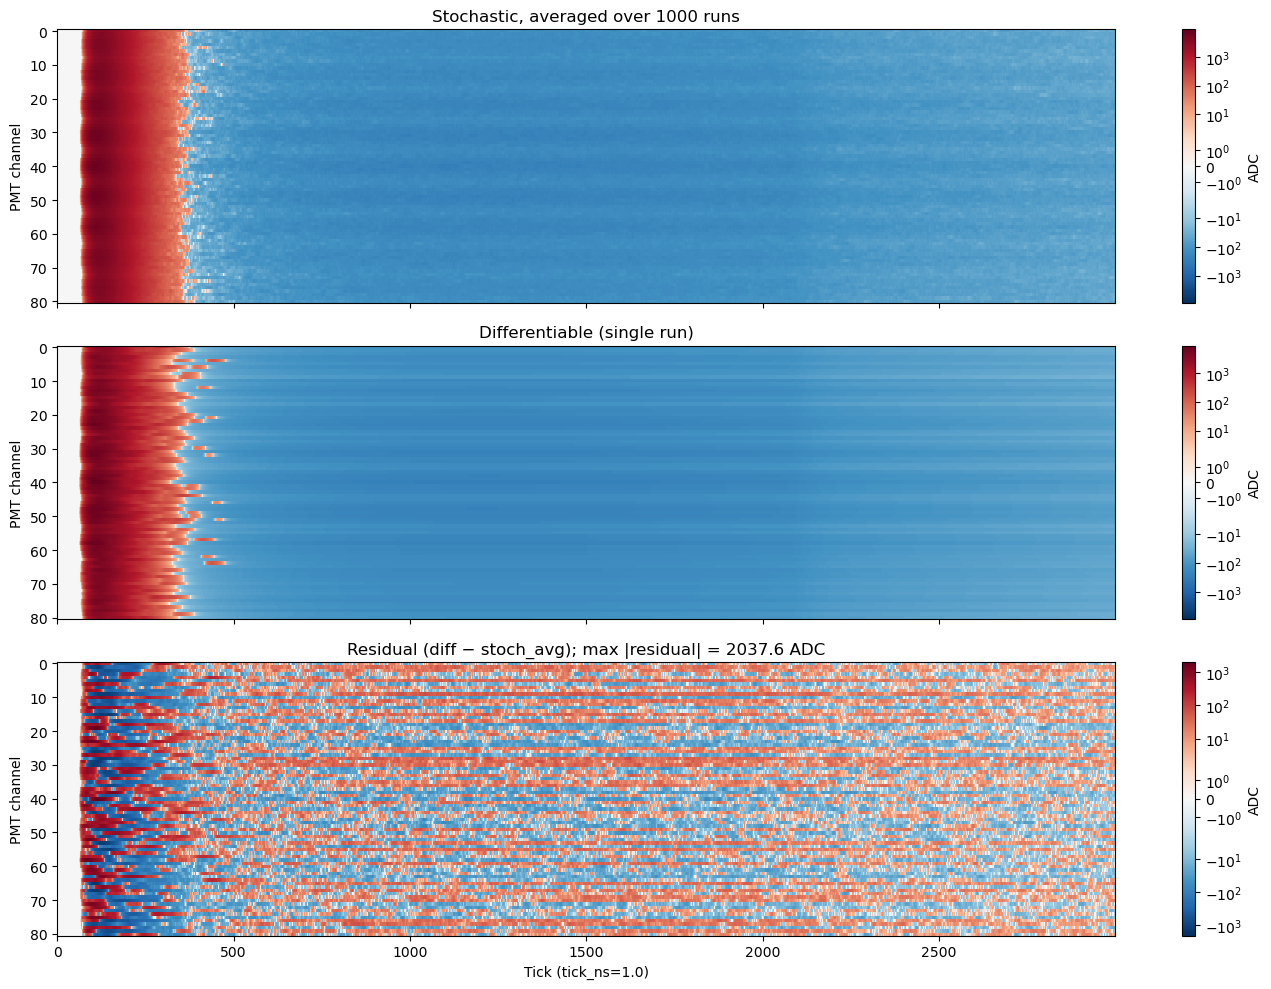

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
vmax = max(abs(stoch_avg_arr).max(), abs(diff_arr).max())

im0 = axes[0].imshow(stoch_avg_arr[:81], aspect="auto", cmap="RdBu_r",
                     vmin=-vmax, vmax=vmax, interpolation="none", norm="symlog")
axes[0].set_title(f"Stochastic, averaged over {N_RUNS} runs")
axes[0].set_ylabel("PMT channel")
plt.colorbar(im0, ax=axes[0], label="ADC")

im1 = axes[1].imshow(diff_arr[:81], aspect="auto", cmap="RdBu_r",
                     vmin=-vmax, vmax=vmax, interpolation="none", norm="symlog")
axes[1].set_title("Differentiable (single run)")
axes[1].set_ylabel("PMT channel")
plt.colorbar(im1, ax=axes[1], label="ADC")

rmax = max(abs(resid_avg).max(), 1e-9)
im2 = axes[2].imshow(resid_avg[:81], aspect="auto", cmap="RdBu_r",
                     vmin=-rmax, vmax=rmax, interpolation="none", norm="symlog")
axes[2].set_title(f"Residual (diff − stoch_avg); max |residual| = {rmax:.1f} ADC")
axes[2].set_xlabel(f"Tick (tick_ns={TICK_NS})")
axes[2].set_ylabel("PMT channel")
plt.colorbar(im2, ax=axes[2], label="ADC")

plt.tight_layout()
plt.show()